In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [6]:
df = load_wine(as_frame=True).frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [8]:
print(df['target'].value_counts())

target
1    71
0    59
2    48
Name: count, dtype: int64


In [7]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [10]:
X = df.drop(columns=['target']) # Features. Variables independientes
y = df['target'] # Target. Variable dependiente
#X2 = df.iloc[:,:-1] # Otra forma de seleccionar las features
#y2 = df.iloc[:,-1] # Otra forma de seleccionar el target

In [11]:
# Split the dataset into training and testing sets
# stratify=y ensures that the class distribution is preserved in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
y_train.value_counts()

target
1    57
0    47
2    38
Name: count, dtype: int64

In [14]:
y_test.value_counts()

target
1    14
0    12
2    10
Name: count, dtype: int64

In [15]:
# Fase de escalado de datos. SVM es sensible a la escala de las variables
# Usamos StandardScaler para estandarizar las features
# Escalamos los datos de entrenamiento y de prueba por separado
# Pero el escalado se ajusta solo con los datos de entrenamiento
# StandardScaler resta la media y divide por la desviación estándar (fórmula: z = (x - mean) / std)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
param_grid = { # Definimos el grid de hiperparámetros a buscar
    'C': [0.1, 1, 10, 100], # Parámetro de regularización
    'gamma': [1, 0.1, 0.01, 0.001, 0.0001], # Coeficiente del kernel RBF
    'kernel': ['rbf', 'linear'] # Tipo de kernel a usar
}
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3, cv=5, n_jobs=-1) # Usa todos los núcleos de la CPU disponibles. Uso un grid search con validación cruzada de 5 pliegues, el grid lo que hace es buscar los mejores hiperparámetros
grid.fit(X_train_scaled, y_train) # Entrenamos el modelo con los datos de entrenamiento escalados

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf', 'linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold 

Mejores hiperparámetros encontrados: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
Accuracy en datos de prueba: 97.22%

Reporte de clasificación:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.93      1.00      0.97        14
           2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36

Matriz de confusión:
 [[12  0  0]
 [ 0 14  0]
 [ 0  1  9]]


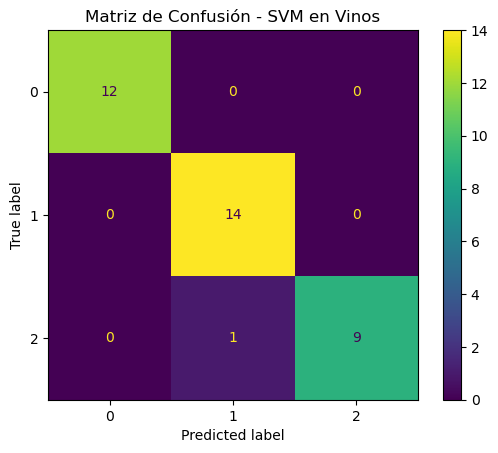

In [18]:
# Evaluamos el modelo en los datos de prueba
y_pred = grid.predict(X_test_scaled) # Hacemos predicciones con los datos de prueba escalados
print("Mejores hiperparámetros encontrados:", grid.best_params_) # Mostramos los mejores hiperparámetros encontrados
print("Accuracy en datos de prueba:", f"{accuracy_score(y_test, y_pred)*100:.2f}%") # Mostramos la exactitud del modelo en los datos de prueba
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred)) # Mostramos el reporte de clasificación
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred)) # Mostramos la matriz de confusión
cm = ConfusionMatrixDisplay.from_estimator(grid, X_test_scaled, y_test) # Mostramos la matriz de confusión de forma gráfica
cm.ax_.set_title('Matriz de Confusión - SVM en Vinos') # Título de la gráfica
plt.show() # Mostramos la gráfica


### Visualización de las fronteras de decisión (opcional)

Accuracy con 2 características: 80.56%


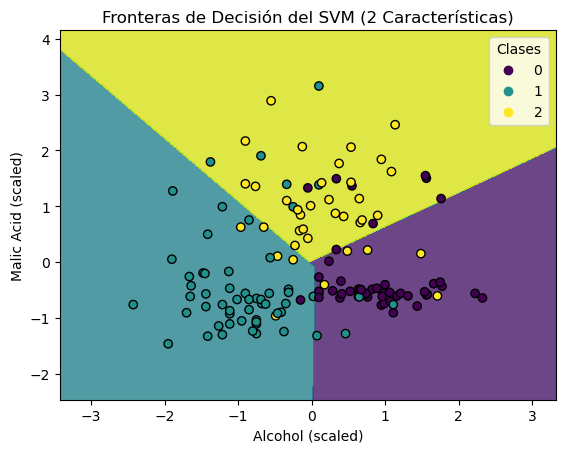

In [21]:
X_reducido = X_train_scaled[:, :2]  # Usamos solo las dos primeras características para visualización
svm_reducido = SVC(C=grid.best_params_['C'], gamma=grid.best_params_['gamma'], kernel=grid.best_params_['kernel'])
svm_reducido.fit(X_reducido, y_train)
y_pred_reducido = svm_reducido.predict(X_test_scaled[:, :2]) # Predicciones con las dos primeras características
print("Accuracy con 2 características:", f"{accuracy_score(y_test, y_pred_reducido)*100:.2f}%")

# Visualización de las fronteras de decisión
x_min, x_max = X_reducido[:, 0].min() - 1, X_reducido[:, 0].max() + 1
y_min, y_max = X_reducido[:, 1].min() - 1, X_reducido[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
Z = svm_reducido.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.8)
scatter = plt.scatter(X_reducido[:, 0], X_reducido[:, 1], c=y_train, edgecolors='k', marker='o')
plt.xlabel('Alcohol (scaled)')
plt.ylabel('Malic Acid (scaled)')
plt.title('Fronteras de Decisión del SVM (2 Características)')
plt.legend(*scatter.legend_elements(), title="Clases")
plt.show()